In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import kagglehub
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

        
path = kagglehub.dataset_download("hassanelfattmi/why-do-customers-leave-can-you-spot-the-churners")

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/home/kimo/instaling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.31M/3.31M [00:00<00:00, 4.84MB/s]

Extracting files...


In [7]:
customer_info = pd.read_csv('/home/kimo/Synder/churn/Customer_Info.csv')
location_data = pd.read_csv('/home/kimo/Synder/churn/Location_Data.csv')
online_services = pd.read_csv('/home/kimo/Synder/churn/Online_Services.csv')
payment_info = pd.read_csv('/home/kimo/Synder/churn/Payment_Info.csv')
service_options = pd.read_csv('/home/kimo/Synder/churn/Service_Options.csv')
status_analysis = pd.read_csv('/home/kimo/Synder/churn/Status_Analysis.csv')

df = status_analysis.merge(service_options, on='customer_id')
df = df.merge(online_services, on='customer_id')
df = df.merge(payment_info, on='customer_id')
df = df.merge(location_data, on='customer_id')
df = df.merge(customer_info, on='customer_id')

In [8]:
X = df.drop(['customer_id', 'churn_label', 'churn_value','churn_category','customer_status','churn_reason','country','zip_code','state','longitude', 
             'latitude','total_population', 'total_population','churn_score','city','total_charges',
            'referred_a_friend','gender','senior_citizen', 'partner', 'number_of_dependents', 'under_30','number_of_referrals'  ], axis=1)
"""
Even though the model would perform better with location data, it was dropped to prevent the model from becoming overly dependent on the city. 
This could lead to predictions based solely on the city, which might be misleading, as some cities have a very low customer count with churn rates at 100%, and not enough sample size to reliably act as a feature. 
The other features were dropped either due to redundancy or because they did not correlate with customer churn, as found in EDA. 
"""
X = pd.get_dummies(X, drop_first= True)
y = status_analysis['churn_value']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False)
xgb_model.fit(X_train, y_train)

# Predict probabilities
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Adjust the threshold
threshold = 0.33
y_pred_adjusted = (y_proba >= threshold).astype(int)

# Evaluate metrics
accuracy_adjusted = accuracy_score(y_test, y_pred_adjusted)
roc_auc_xgb = roc_auc_score(y_test, y_proba)
report_adjusted = classification_report(y_test, y_pred_adjusted)
df['churn_prob'] = xgb_model.predict_proba(X_scaled)[:, 1]
print(accuracy_adjusted)
print(roc_auc_xgb)
print(report_adjusted)

0.9510290986515259
0.9906735536762347
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1036
           1       0.90      0.92      0.91       373

    accuracy                           0.95      1409
   macro avg       0.93      0.94      0.94      1409
weighted avg       0.95      0.95      0.95      1409



/home/kimo/instaling/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [05:12:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.96


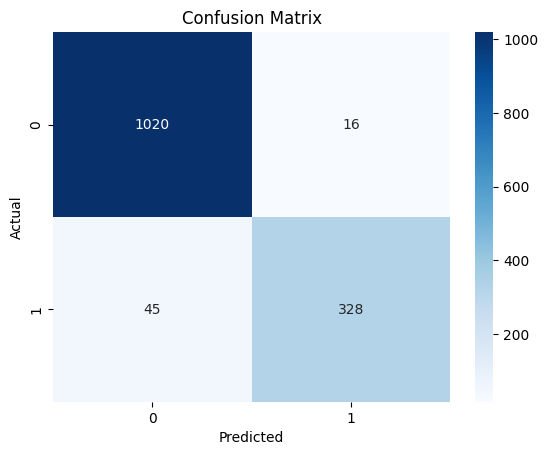

In [9]:
y_pred = xgb_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import joblib

# 1. Save the trained XGBoost model
joblib.dump(xgb_model, "churn_prediction.pkl")